# Exploratory Data Analysis

## Imports

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
sns.set_theme(style="whitegrid")

## Data

In [32]:
data_folder = '../data/'

# load the training data (2022-2024)
df_2022 = pd.read_parquet(os.path.join(data_folder, 'train/play_by_play_2022.parquet'))
df_2023 = pd.read_parquet(os.path.join(data_folder, 'train/play_by_play_2023.parquet'))
df_2024 = pd.read_parquet(os.path.join(data_folder, 'train/play_by_play_2024.parquet'))

# merge into one big training dataset
train_df = pd.concat([df_2022, df_2023, df_2024], ignore_index=True)

# filter dataset to only include 'run' and 'pass' plays
valid_plays = ['run', 'pass']
train_df = train_df[train_df['play_type'].isin(valid_plays)].copy()

## EDA

In [33]:
# Make sure we're above the 50,000 play threshold for the rubric
print(f"Valid plays in training set: {len(train_df)}")
print(f"Number of columns: {len(train_df.columns)}")

Valid plays in training set: 106080
Number of columns: 372


In [34]:
# filter columns to only include those that are relevant for modeling
features_to_keep = [
    'play_type', 'down', 'ydstogo', 'yardline_100', 
    'score_differential', 'qtr', 'half_seconds_remaining'
]
clean_train_df = train_df[features_to_keep].copy()
clean_train_df.head()

,play_type,down,ydstogo,yardline_100,score_differential,qtr,half_seconds_remaining
2,run,1.0,10.0,78.0,0.0,1.0,1796.0
3,pass,1.0,10.0,59.0,0.0,1.0,1769.0
4,run,2.0,10.0,59.0,0.0,1.0,1765.0
5,pass,3.0,5.0,54.0,0.0,1.0,1741.0
7,pass,1.0,10.0,72.0,0.0,1.0,1722.0


In [14]:
# Missing values per columns
missing_values = clean_train_df.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
play_type                   0
down                      399
ydstogo                     0
yardline_100                0
score_differential          0
qtr                         0
half_seconds_remaining      0
dtype: int64


## Baseline
What does the baseline distribution look like?

Overall Play Call Tendencies:
play_type
pass    57.618778
run     42.381222
Name: proportion, dtype: float64


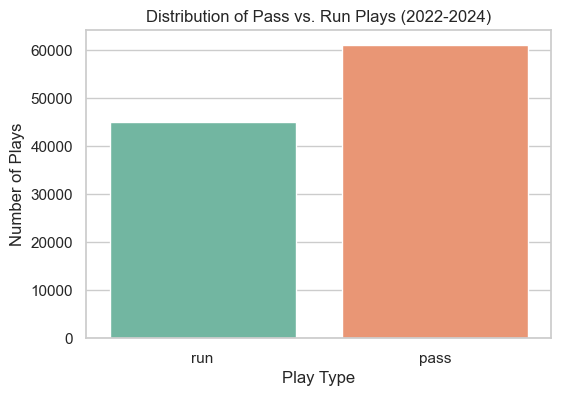

In [19]:
# calculate run vs pass ratio
target_dist = clean_train_df['play_type'].value_counts(normalize=True) * 100

print("Overall Play Call Tendencies:")
print(target_dist)

# VISUAL 1: A simple bar chart of the target variable
plt.figure(figsize=(6, 4))

# UPDATED LINE HERE: Added hue='play_type' and legend=False
sns.countplot(data=clean_train_df, x='play_type', hue='play_type', palette='Set2', legend=False)

plt.title('Distribution of Pass vs. Run Plays (2022-2024)')
plt.ylabel('Number of Plays')
plt.xlabel('Play Type')
plt.show()

## Bivariate Analysis
How do individual features affeect play type?

### Feature: *Down*
Does what down it is affect a coaches decision in running/passing?

Run/Pass Percentage by Down:
play_type       pass        run
down                           
1.0        47.962627  52.037373
2.0        58.937308  41.062692
3.0        75.299497  24.700503
4.0        61.016949  38.983051


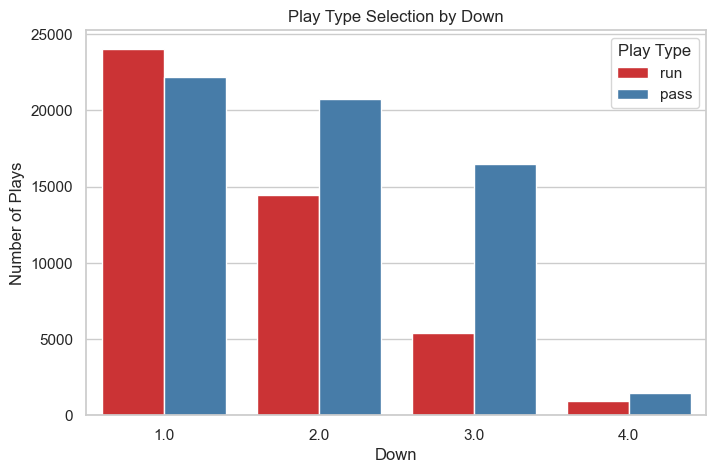

In [20]:
# Group by down and calculate the percentage of runs vs passes
down_tendencies = clean_train_df.groupby('down')['play_type'].value_counts(normalize=True).unstack() * 100
print("Run/Pass Percentage by Down:")
print(down_tendencies)

# VISUAL 2: Grouped Bar Chart for Downs
plt.figure(figsize=(8, 5))
sns.countplot(data=clean_train_df, x='down', hue='play_type', palette='Set1')
plt.title('Play Type Selection by Down')
plt.ylabel('Number of Plays')
plt.xlabel('Down')
plt.legend(title='Play Type')
plt.show()

### Feature: *Yards to Go*
Does how close a team is to getting a first down determine run/pass?

Play-Calling Breakdown by Yardage Segment (%):
play_type                 pass        run
ydstogo_segment                          
Short (1-3 yds)      42.100563  57.899437
Medium (4-7 yds)     63.935877  36.064123
Long (8-10 yds)      55.240204  44.759796
Very Long (11+ yds)  78.569510  21.430490


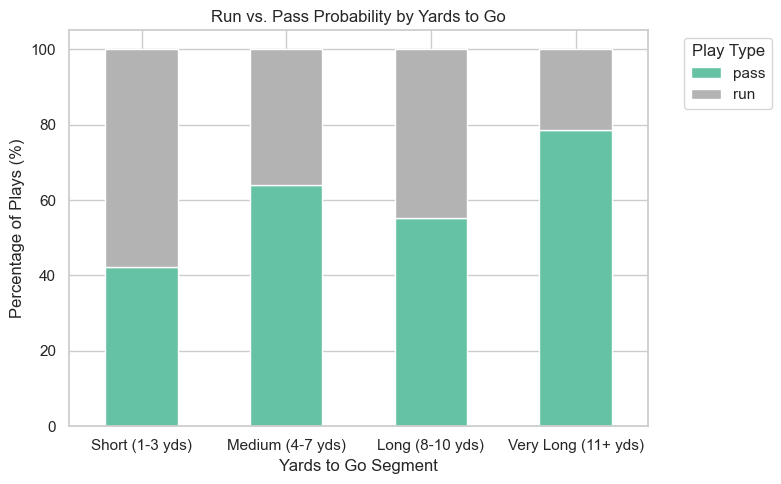

In [35]:
# 1. Create logical yardage segments
bins = [0, 3, 7, 10, 100]
labels = ['Short (1-3 yds)', 'Medium (4-7 yds)', 'Long (8-10 yds)', 'Very Long (11+ yds)']

clean_train_df['ydstogo_segment'] = pd.cut(clean_train_df['ydstogo'], 
                                           bins=bins, 
                                           labels=labels)

# 2. Calculate the run vs. pass percentages for each segment
yardage_tendencies = clean_train_df.groupby('ydstogo_segment', observed=False)['play_type'].value_counts(normalize=True).unstack() * 100

print("Play-Calling Breakdown by Yardage Segment (%):")
print(yardage_tendencies)

# 3. Plot a Stacked Bar Chart
yardage_tendencies.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Set2')

plt.title('Run vs. Pass Probability by Yards to Go')
plt.ylabel('Percentage of Plays (%)')
plt.xlabel('Yards to Go Segment')
plt.legend(title='Play Type', bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside the plot
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Feature: *Score Differential*
Does how close a game is determine if a coach passes or runs?

In [30]:
# Create a temporary column to group the game state
clean_train_df['game_script'] = pd.cut(clean_train_df['score_differential'], 
                                 bins=[-100, -8, 8, 100], 
                                 labels=['Trailing Big', 'Close Game', 'Leading Big'])

script_tendencies = clean_train_df.groupby('game_script', observed=False)['play_type'].value_counts(normalize=True).unstack() * 100

print("\nPlay Calling Based on Score Differential:")
print(script_tendencies)


Play Calling Based on Score Differential:
play_type          pass        run
game_script                       
Trailing Big  68.205699  31.794301
Close Game    56.427108  43.572892
Leading Big   46.059742  53.940258
